In [1]:
# ------------------------------------
# Save location for plots and gifs
# ------------------------------------
SAVE_DIR = './figures/dynamics'



# ------------------------------------
# Imports
# ------------------------------------
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter



# ------------------------------------
# Mathematical/logical functions
# ------------------------------------

def lin_comb(coeffs,vectors):
    psi = np.zeros(len(vectors[0]), dtype=complex)
    j = 0
    while j < len(vectors):
        psi += coeffs[j]*vectors[j]
        j+=1
    return psi

def normalized_density(x,psi):
    return np.conj(psi)*psi*np.trapz(np.conj(psi)*psi,x)**(-1)

def local_density(x,low,high,density):
    low_idx = np.argsort((x-low)**2)[0]
    high_idx = np.argsort((x-high)**2)[0]
    return np.trapz(density[low_idx:high_idx],x[low_idx:high_idx])

def projection(x,psi,basis):
    c = []
    for phi_j in basis:
        c.append(np.trapz(psi*phi_j,x)/np.trapz(phi_j*phi_j,x))
    return c

def timestep(x,t,c_initial,basis_E):
    return c_initial*np.exp(-1.0j*basis_E*t)

def T_ij(x,dx,psii,psij):
    # <psi_j|T|psi_i>
    scnd_deriv_psii = (-1/(2*dx**2))*(np.roll(psii, -1) + np.roll(psii, 1) - 2*psii)
    return np.trapz(np.conj(psij)*scnd_deriv_psii,x)

def V_ij(x,potential,psii,psij):
    # <psi_j|V|psi_i>
    return np.trapz(np.conj(psij)*potential*psii,x)

def H_ij(x,dx,potential,psii,psij):
    return T_ij(x,dx,psii,psij) + V_ij(x,potential,psii,psij)

def normalize(x,psi):
    norm = np.sqrt(np.trapz(np.conj(psi)*psi, x))
    return psi/norm

1. We begin by specifying the 1D space, including the boundaries (xmax, xmin) and the number of discrete points in space (N).  N must be large enough to converge the properties of the resonance. However, because the Hamiltonian diagonalizations will be performed in the basis of the discrete points of space, N must be small enough for these calculations to remain tractable.

In [2]:
# ------------------------------------
# Preparing 1D space
# ------------------------------------
N = 2000
xmax = 200
xmin = -200

dx = (xmax-xmin)/N
x = np.linspace(xmin,xmax,N)

2. For the dynamical approach using the time-dependent Schrodinger equation, two related potentials are used.  Both potentials feature a well centered at zero.  The first potential, Vb, supports a single bound state where the particle density is confined to the well.  The second potential, Vm, supports a single metastable state (resonance) because the particle can tunnel out of the well (this is what we will observe in the next few calculations).  The resonance we are studying is the one supported by Vm, and we will use Vb to prepare an initial state that represents a particle inside the well.

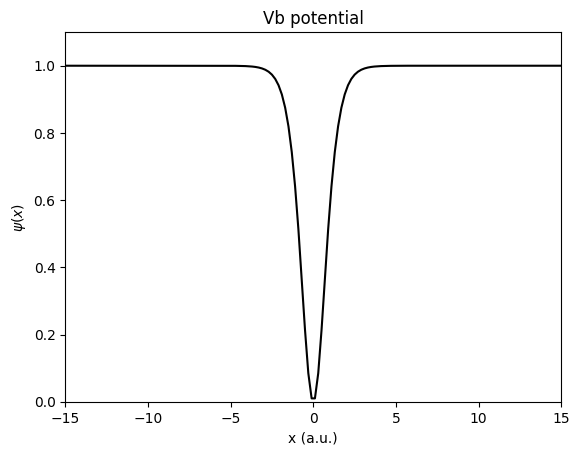

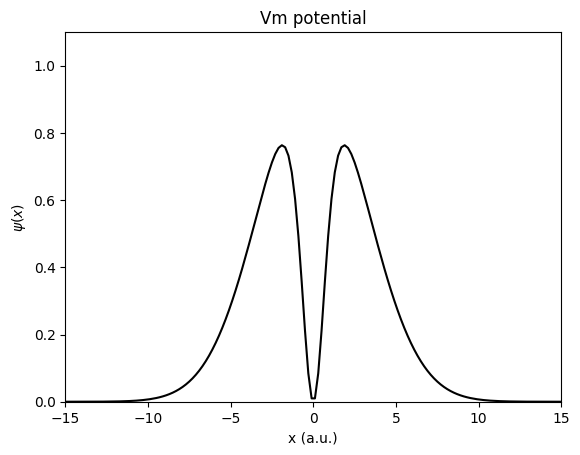

<Figure size 640x480 with 0 Axes>

In [3]:
# ------------------------------------
# Preparing potential surfaces
# ------------------------------------
def Vb(x):
    # A system supporting a single bound state
    V0 = 1
    alpha = 0
    beta = 1
    return (1-V0/np.cosh(beta*x)**2)*np.exp(-alpha*x**2)

def Vm(x):
    # A system supporting a single metastable state
    V0 = 1
    alpha = 0.05
    beta = 1
    return (1-V0/np.cosh(beta*x)**2)*np.exp(-alpha*x**2)

Vb_potential = Vb(x)
Vm_potential = Vm(x)



# ------------------------------------
# Plotting potential surfaces
# ------------------------------------
plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.1)
plt.xlim(left=-15.0,right=15.0)
plt.plot(x,Vb_potential,color='black')
plt.title('Vb potential')
plt.savefig(os.path.join(SAVE_DIR,'Vb_potential.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.1)
plt.xlim(left=-15.0,right=15.0)
plt.plot(x,Vm_potential,color='black')
plt.title('Vm potential')
plt.savefig(os.path.join(SAVE_DIR,'Vm_potential.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

3. [Runtime ~ 15 sec] We now construct the Hamiltonians for each system in atomic units and diagonalize them.  The resulting eigenstates are plotted in light blue, with notable eigenstates being a darker blue. The eigenstates are not normalized, and they are shifted vertically based on their respective energies.  We observe in the bound system: there is a single eigenstate at 0.5 au of energy representing a particle confined to the well, while all other eigenstates are significantly higher in energy.  We observe in the metastable system: there are a set of discretized continuum eigenstates in the vacinity of 0.5 au of energy that have significant amplitude inside the well but also extend outside it.

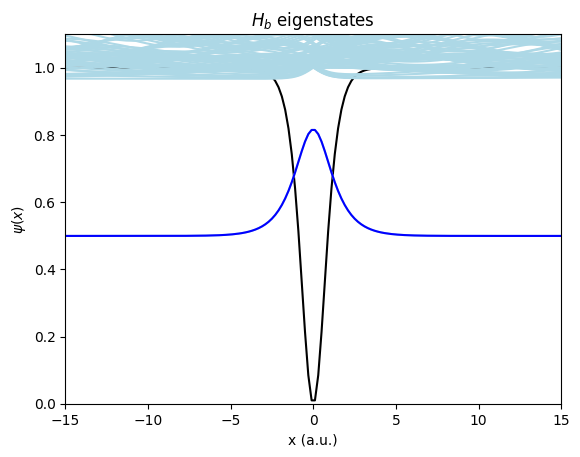

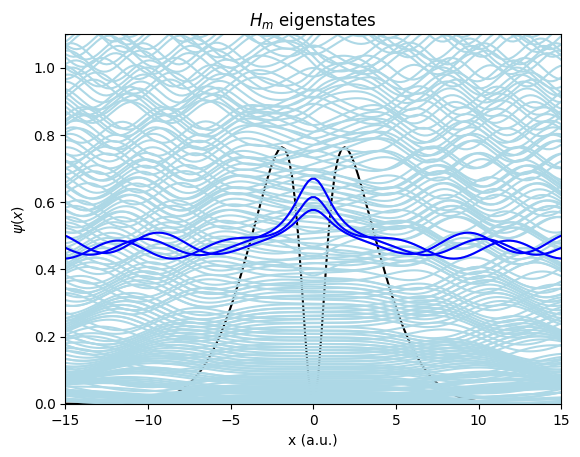

<Figure size 640x480 with 0 Axes>

In [4]:
# ------------------------------------
# Constructing bound system Hamiltonian
# ------------------------------------
Hb = np.zeros((N,N))

for i in range(N):
  for j in range(N):
    if i == j+1:
      Hb[i,j] = -1/(2*dx**2)
    if i == j:
      Hb[i,j] = 1/(dx**2) + Vb_potential[i]
    if i == j-1:
      Hb[i,j] = -1/(2*dx**2)



# ------------------------------------
# Constructing metastable system Hamiltonian
# ------------------------------------
Hm = np.zeros((N,N))

for i in range(N):
  for j in range(N):
    if i == j+1:
      Hm[i,j] = -1/(2*dx**2)
    if i == j:
      Hm[i,j] = 1/(dx**2) + Vm_potential[i]
    if i == j-1:
      Hm[i,j] = -1/(2*dx**2)



# ------------------------------------
# Diagonalizing bound system Hamiltonian
# ------------------------------------
wb,vb = np.linalg.eig(Hb)

sorter = np.argsort(wb)
wb = wb[sorter]
vb = vb.T
vb = vb[sorter]



# ------------------------------------
# Diagonalizing metastable system Hamiltonian
# ------------------------------------
wm,vm = np.linalg.eig(Hm)

sorter = np.argsort(wm)
wm = wm[sorter]
vm = vm.T
vm = vm[sorter]



# ------------------------------------
# Plotting eigenstates
# ------------------------------------
plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.1)
plt.xlim(left=-15.0,right=15.0)
plt.plot(x,Vb_potential,color='black')
i = 0
while i < 200:
  plt.plot(x,-vb[i]+wb[i],color='lightblue')
  i+=1
plt.plot(x,-vb[0]+wb[0],color='blue')
plt.title(r'$H_{b}$ eigenstates')
plt.savefig(os.path.join(SAVE_DIR,'Hb_eigenstates.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.1)
plt.xlim(left=-15.0,right=15.0)
plt.plot(x,Vm_potential,color='black')
i = 0
while i < 200:
  plt.plot(x,-vm[i]+wm[i],color='lightblue')
  i+=1
plt.plot(x,-vm[118]+wm[118],color='blue')
plt.plot(x,-vm[120]+wm[120],color='blue')
plt.plot(x,-vm[122]+wm[122],color='blue')
plt.title(r'$H_{m}$ eigenstates')
plt.savefig(os.path.join(SAVE_DIR,'Hm_eigenstates.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

4. We now prepare our metastable system such that there is a particle inside the well. This is accomplished by projecting the bound eigenstate of the Vb system onto the full set of discretized continuum eigenstates in the Vm system. This projection yields a quantum state of Hm composed of a specific linear combination of Hm eigenstates, which is plotted below.  This state represents a particle inside the well of the metastable system, and we can watch as this particle tunnels out of the well by operating on this state with the time evolution operator derived from the TDSE.

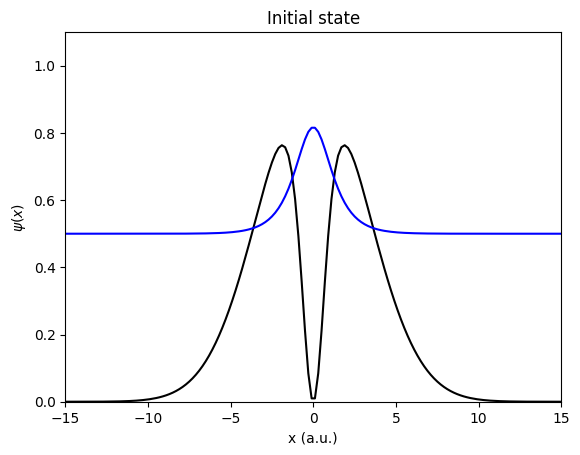

<Figure size 640x480 with 0 Axes>

In [5]:
# ------------------------------------
# Projection
# ------------------------------------
c = projection(x,vb[0],vm)
psi = lin_comb(c,vm)



# ------------------------------------
# Plotting the initial state
# ------------------------------------
plt.xlabel('x (a.u.)')
plt.ylabel(r'$\psi(x)$')
plt.ylim(bottom=0,top=1.1)
plt.xlim(left=-15.0,right=15.0)
plt.plot(x,np.real(Vm_potential),color='black')
plt.plot(x,np.real(-psi+0.5),color='blue')
plt.title('Initial state')
plt.savefig(os.path.join(SAVE_DIR,'initial_state.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

5. [Runtime ~ 20 sec] We now apply the time evolution operator to the initial state. More specifically, we are calculating instances of the wavefunction at regular intervals over a period of 200 au of time. Using these wavefunction instances, we are able to also calculate the particle density and energy as functions of time. Gifs of the wavefunction and density changing over time are saved. If we consider the particle density and energy over all space (integrating over all space), we would expect that the density and energy would be conserved over the entire simulation, which is not particularly interesting. However, if we consider how these properties are changing in the region of the well (integrating over only the region of the well), we observe that after a brief period the energy remains constant and the density decreases exponentially. The energy is the resonance energy (ER), and by plotting the negative log of the density over time and taking the slope we find the resonance width (Gamma).

Energy = 0.4640976090529818 a.u.
Width = 0.00923557738784646 a.u.


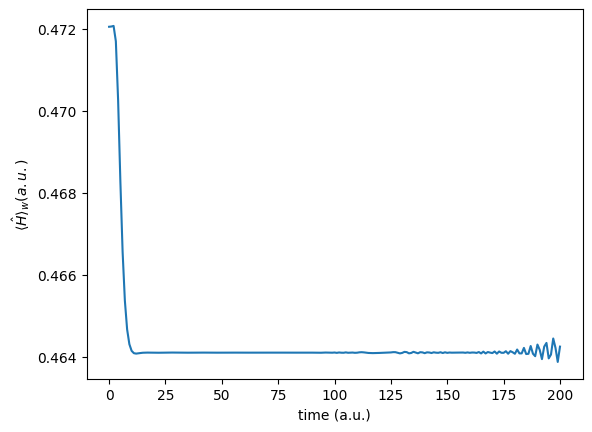

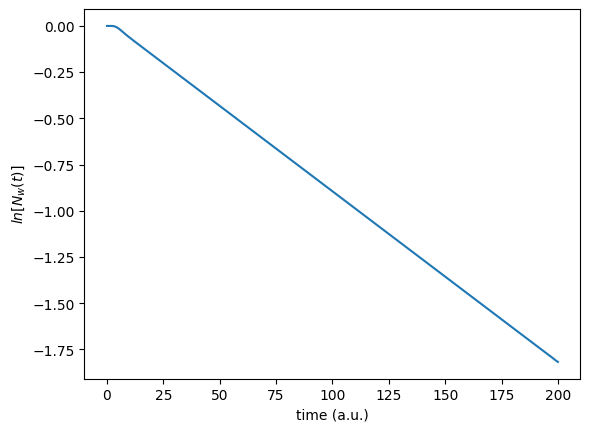

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [6]:
# ------------------------------------
# Time evolution
# ------------------------------------
time = np.linspace(0,200,201)

idx_of_5 = np.argsort((x-5)**2)[0]
idx_of_neg_5 = np.argsort((x+5)**2)[0]
psi_t = []
energy_t = []
density_t = []
for t in time:
    c_t = timestep(x,t,c,wm)
    psi_tau = lin_comb(c_t,vm)
    psi_t.append(psi_tau)
    energy_t.append(H_ij(x[idx_of_neg_5:idx_of_5],
                         dx,
                         Vm_potential[idx_of_neg_5:idx_of_5],
                         normalize(x[idx_of_neg_5:idx_of_5],psi_tau[idx_of_neg_5:idx_of_5]),
                         normalize(x[idx_of_neg_5:idx_of_5],psi_tau[idx_of_neg_5:idx_of_5])))
    density_t.append(normalized_density(x,psi_tau))



# ------------------------------------
# Calculating resonance energy and width
# ------------------------------------
energy = np.real(energy_t[25])
print('Energy =',energy,'a.u.')

log_well_density_t = []
for dens in density_t:
    log_well_dens = np.log(local_density(x,-5,5,dens))
    log_well_density_t.append(log_well_dens)

m, b = np.polyfit(time[25:200],log_well_density_t[25:200],1)

width = -np.real(m)
print('Width =',width,'a.u.')



# ------------------------------------
# Plotting energy and density in the region of the well over time
# ------------------------------------
plt.plot(time,np.real(energy_t))
plt.xlabel('time (a.u.)')
plt.ylabel(r'$\langle \hat{H} \rangle_{w} (a.u.)$')
plt.savefig(os.path.join(SAVE_DIR,'well_energy.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()

plt.plot(time,np.real(log_well_density_t))
plt.xlabel('time (a.u.)')
plt.ylabel(r'$ln[N_{w}(t)]$')
plt.savefig(os.path.join(SAVE_DIR,'log_well_dens.png'),dpi=300,format='png',bbox_inches='tight')
plt.show()
plt.clf()



# ------------------------------------
# Producing gifs of the wavefunction and density over time
# ------------------------------------
fig = plt.figure()
metadata = dict(title='Movie',artist='SF')
writer = PillowWriter(fps=30,metadata=metadata)
with writer.saving(fig,os.path.join(SAVE_DIR,'density_evolution.gif'),100):
    j = 0
    while j < len(time):
        plt.plot(x,np.real(density_t[j]+0.5),color='blue',label='time (a.u.) = '+str(time[j]))
        plt.plot(x,Vm_potential,color='black')
        plt.xlabel('x (a.u.)')
        plt.ylabel(r'$|\psi(x)|^2$')
        plt.legend()
        plt.ylim(bottom=0,top=1.1)
        plt.xlim(left=-15.0,right=15.0)
        writer.grab_frame()
        plt.clf()
        j+=1

fig = plt.figure()
metadata = dict(title='Movie',artist='SF')
writer = PillowWriter(fps=30,metadata=metadata)
with writer.saving(fig,os.path.join(SAVE_DIR,'wvfxn_evolution.gif'),100):
    j = 0
    while j < len(time):
        plt.plot(x,np.imag(normalize(x,psi_t[j]))+0.5,color='skyblue',label=r'Im($\psi$) time (a.u.) = '+str(time[j]))
        plt.plot(x,np.real(normalize(x,psi_t[j]))+0.5,color='blue',label=r'Re($\psi$) time (a.u.) = '+str(time[j]))
        plt.plot(x,Vm_potential,color='black')
        plt.xlabel('x (a.u.)')
        plt.ylabel(r'$\psi(x)$')
        plt.legend()
        plt.ylim(bottom=0,top=1.1)
        plt.xlim(left=-15.0,right=15.0)
        writer.grab_frame()
        plt.clf()
        j+=1

fig = plt.figure()
metadata = dict(title='Movie',artist='SF')
writer = PillowWriter(fps=30,metadata=metadata)
with writer.saving(fig,os.path.join(SAVE_DIR,'wvfxn_evolution_wide.gif'),100):
    j = 0
    while j < len(time):
        plt.plot(x,np.imag(normalize(x,psi_t[j]))+0.5,color='skyblue',label=r'Im($\psi$) time (a.u.) = '+str(time[j]))
        plt.plot(x,np.real(normalize(x,psi_t[j]))+0.5,color='blue',label=r'Re($\psi$) time (a.u.) = '+str(time[j]))
        plt.plot(x,Vm_potential,color='black')
        plt.xlabel('x (a.u.)')
        plt.ylabel(r'$\psi(x)$')
        plt.legend()
        plt.ylim(bottom=0,top=1.1)
        plt.xlim(left=-200.0,right=200.0)
        writer.grab_frame()
        plt.clf()
        j+=1